In [1]:
import numpy as np

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [2]:
iris = load_iris()

# Take only 2 features for 2D visualization
# Sepal Length (0) and Petal Length (2)
X = iris.data[:, [0, 2]]

# Target labels
y = iris.target

# Convert into Binary Classification
# Setosa = 0 , Others = 1
y = np.where(y == 0, 0, 1)

In [3]:
# ---------------- INITIALIZE WEIGHTS ----------------
w = np.zeros(2)
b = 0

lr = 0.1
epochs = 30

In [4]:
# ---------------- PERCEPTRON PREDICT FUNCTION ----------------


def predict(x):
    return np.where(np.dot(x, w) + b >= 0, 1, 0)

In [5]:
# ---------------- TRAINING ----------------
for epoch in range(epochs):
    for i in range(len(X)):
        y_pred = predict(X[i])
        error = y[i] - y_pred
        
        w = w + lr * error * X[i]
        b = b + lr * error

print("Training Completed")
print("Weights:", w)
print("Bias:", b)

Training Completed
Weights: [-0.34  0.91]
Bias: -0.2


In [6]:
# ---------------- DECISION REGION ----------------
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.05),
    np.arange(y_min, y_max, 0.05)
)

# Predict on grid
Z = predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

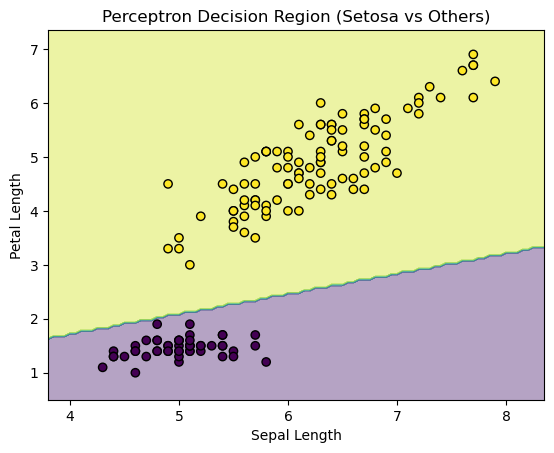

In [7]:
# ---------------- PLOT ----------------
plt.contourf(xx, yy, Z, alpha=0.4)

plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Perceptron Decision Region (Setosa vs Others)")

plt.show()